# PassiveROI: climate and plausibility checks

Executed against cached NASA POWER 2025 data. This notebook checks arithmetic, direction and rough scale; **it does not validate engineering accuracy**.

The supplied Zawaya Mall numbers (625.5 → 363.2 kWh/m²/year) are from the project brief. An independent source and original simulation inputs were not available. They may describe thermal cooling demand, so absolute values must not be equated with electrical intensity. No model coefficients have been fitted to this comparator.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from src.config import CITIES
from src.climate import load_climate, provenance
from src.energy_model import Design, Settings, compare
from src.financial_model import investment_case
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
climate_rows=[]
for city in CITIES:
    d=load_climate(city)
    climate_rows.append({'City':city,'Days':len(d),'CDD18':round((d.t_mean-18).clip(lower=0).sum(),1),'August mean daily high °C':round(d.loc[d.index.month==8,'t_max'].mean(),1),'Annual GHI kWh/m²':round(d.ghi.sum(),1)})
pd.DataFrame(climate_rows)

Out[2]: 
        City  Days   CDD18  August mean daily high °C  Annual GHI kWh/m²
0  Abu Dhabi   365  3903.7                       39.6             2012.7
1      Dubai   365  3996.5                       40.3             1966.2
2      Cairo   365  2064.5                       39.0             2088.7


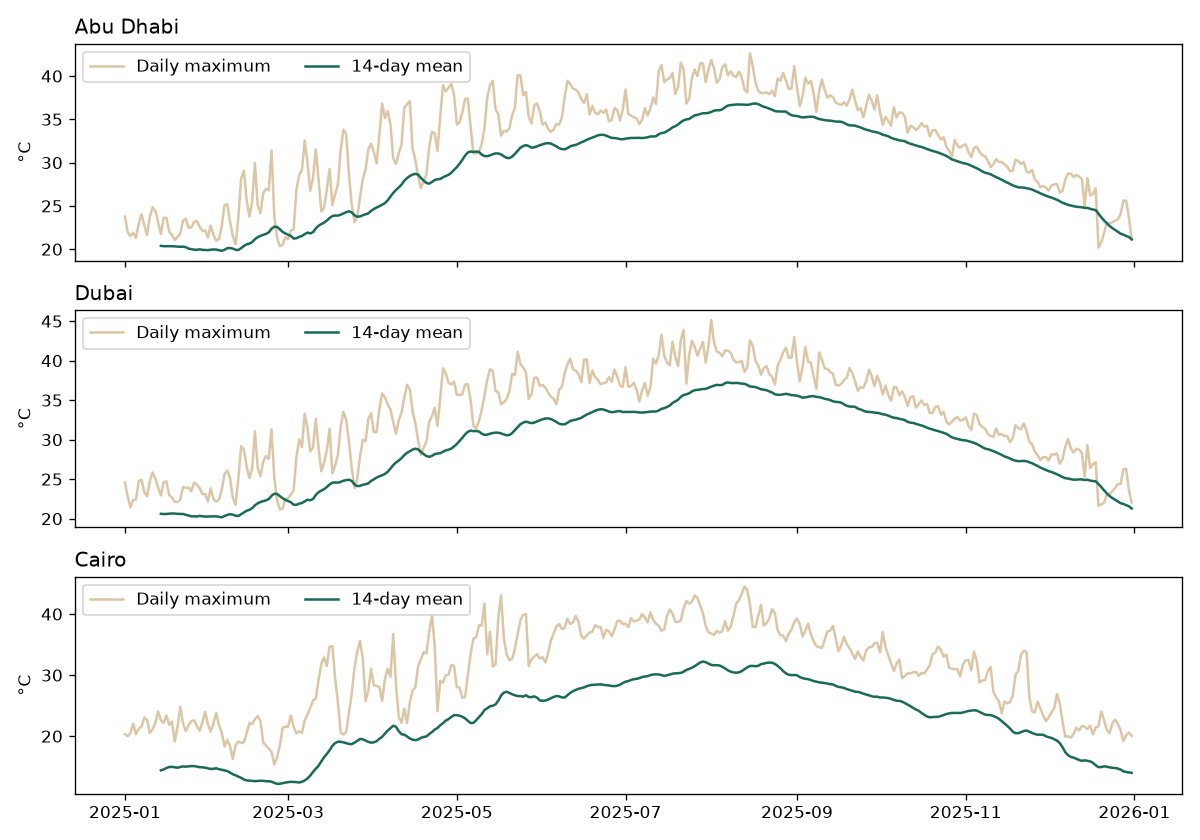

In [3]:
fig,axes=plt.subplots(3,1,figsize=(10,7),sharex=True)
for ax,city in zip(axes,CITIES):
    d=load_climate(city)
    ax.plot(d.index,d.t_max,color='#c4a16a',alpha=.6,label='Daily maximum')
    ax.plot(d.index,d.t_mean.rolling(14).mean(),color='#176b57',label='14-day mean')
    ax.set_title(city,loc='left'); ax.set_ylabel('°C'); ax.legend(ncol=2,loc='upper left')
fig.tight_layout()
from io import BytesIO
from IPython.display import display, Image
figure_buffer=BytesIO()
fig.savefig(figure_buffer,format='png',dpi=120)
display(Image(data=figure_buffer.getvalue()))
plt.close(fig)

## Comparable intervention categories, not a recreated mall

Cairo commercial example: 2,000 m², two storeys, 40% glazing, legacy envelope, COP 3. Change dominant glazing from west to north, add deep shading, and apply a hypothetical 10% sensible air-exchange credit. Keep insulation, glazing ratio and all other inputs constant. The dominant glazing allocation is physically capped by available facade area. The experimental ventilation credit is not an enthalpy-based natural ventilation calculation.

In [4]:
baseline=Design()
proposed=Design(orientation='North',shading='Deep',ventilation_credit=.10)
r=compare(load_climate('Cairo'),baseline,proposed,Settings())
claimed=100*(625.5-363.2)/625.5
print(f"Supplied comparator: {claimed:.2f}%")
print(f"Model scenario: {r['reduction_pct']:.2f}%")
print(f"Gap: {claimed-r['reduction_pct']:.2f} percentage points")
pd.DataFrame([{'Scenario':key,'Cooling electricity kWh/m²/year':r[key]['kwh_per_sqm'],'Sensible thermal cooling kWh/m²/year':r[key]['thermal_kwh_per_sqm']} for key in ['baseline','proposed']])

Supplied comparator: 41.93%
Model scenario: 22.13%
Gap: 19.80 percentage points
Out[4]: 
   Scenario  ...  Sensible thermal cooling kWh/m²/year
0  baseline  ...                            225.398304
1  proposed  ...                            175.510330

[2 rows x 3 columns]


The reduction is positive and of a similar broad scale, but differs materially from the supplied benchmark. Differences in geometry, humidity, schedules, actual shading, weather and model structure could all matter. This is not a calibrated or independently validated model. A positive and sub-100% result alone is not evidence of accuracy. Future validation needs actual inputs and an independent simulation or metered cooling dataset.

In [5]:
assert 0 < r['reduction_pct'] < 100
case=investment_case(1000,1,1000,years=2,discount_rate=.10)
expected=-1000+1000/1.1+1000/1.1**2
assert abs(case['npv']-expected)<1e-9
assert case['payback_years']==1
print(f"Hand-calculated NPV: {expected:.2f}; model NPV: {case['npv']:.2f}")
print('Arithmetic checks passed; no engineering accuracy claim.')

Hand-calculated NPV: 735.54; model NPV: 735.54
Arithmetic checks passed; no engineering accuracy claim.
